In [35]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [4]:
emb_datapath = "/home/zachkaras/fmri/fmri_model/analysis/fir/midprocess/133/code_keystroke_embeddings.pkl"

with open(emb_datapath, 'rb') as f:
    embedding_dict = pickle.load(f)
    
    
keystroke_path = "/home/zachkaras/fmri/fmri_model/analysis/fir/midprocess/133/code_formatted_keystrokes.pkl"

with open(keystroke_path, 'rb') as f:
    keystroke_dict = pickle.load(f)

In [38]:
layers = embedding_dict[(keystroke_dict[55])].keys()

signal = { l : [] for l in layers }
for vol,keys in keystroke_dict.items():
    
    if keys == '':
        continue
    
    layers = embedding_dict[keys]
    for l, emb in layers.items():
        signal[l].append(emb)
    # break

    # np.append(emb)

signal = { l : np.vstack(v) for l,v in signal.items()}    


In [41]:
signal['layer_0'].shape

(688, 3072)

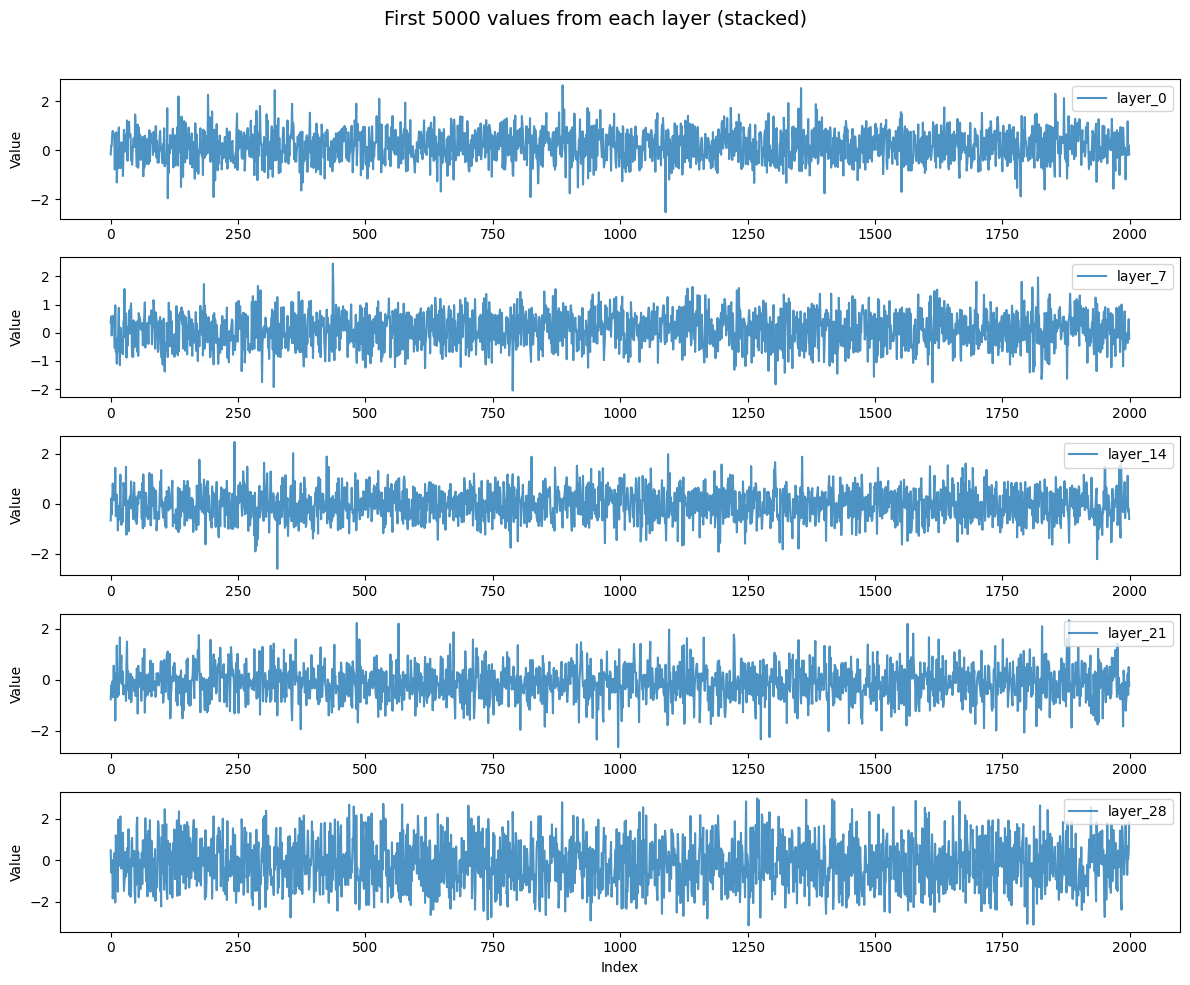

In [36]:

plt.figure(figsize=(12, 10))

for i, (key, values) in enumerate(signal.items(), 1):
    plt.subplot(5, 1, i)
    plt.plot(values[:2000], label=key, alpha=0.8)
    plt.ylabel("Value")
    plt.legend(loc="upper right")
    if i == 5:
        plt.xlabel("Index")

plt.suptitle("First 5000 values from each layer (stacked)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# TODO - downsample the signal to match 